# Mushroom Classification — Can Machine Learning Identify Whether a Mushroom is Edible or Poisonous?

**Nama:** _Claura Sita Ramdiny_

**NIM:** _09020182529016_

**Take-Home Challenge:** Machine Learning & Deep Learning — Binary Classification


## 1. Problem Definition

**1. Apa permasalahan utama yang ingin diselesaikan?**
Menentukan apakah sebuah jamur aman dikonsumsi (*edible*) atau berbahaya (*poisonous*) berdasarkan ciri-ciri fisiknya (bentuk tudung, warna, aroma, dsb), tanpa harus mengandalkan identifikasi manual oleh ahli mikologi.

**2. Apakah permasalahan ini termasuk Classification atau Regression?**
Ini adalah masalah **Classification**, karena target yang diprediksi berupa **kategori diskrit** (edible / poisonous), bukan nilai numerik kontinu.

**3. Apa target yang akan diprediksi?**
Kolom `class`, dengan dua nilai: `e` (edible) dan `p` (poisonous).

**4. Mengapa permasalahan ini termasuk Classification?**
Karena output yang diinginkan adalah label kelas, bukan besaran yang bisa diukur dalam skala kontinu — pertanyaannya "termasuk kelompok mana?", bukan "berapa nilainya?". Selain itu, konsekuensi dari prediksi (aman dimakan vs beracun) bersifat kategorikal dan biner, bukan gradasi.

**5. Apa output yang diharapkan dari model?**
Label prediksi (0 = edible, 1 = poisonous) untuk setiap jamur baru, idealnya disertai tingkat keyakinan (probability), karena kesalahan memprediksi *poisonous* sebagai *edible* (False Negative) jauh lebih berbahaya daripada sebaliknya.


## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & split
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report,
                              mean_absolute_error, mean_squared_error, r2_score)

# Interpretation
from sklearn.inspection import permutation_importance

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Settings
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)


## 3. Load Dataset

In [3]:
df = pd.read_csv('../data/mushrooms.csv')
df.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


## 4. Data Understanding

Sebelum melakukan apa pun, kita perlu memahami bentuk dan isi dataset: berapa baris/kolom, tipe data tiap kolom, apakah ada nilai kosong, seberapa banyak kategori di tiap fitur, dan bagaimana sebaran target.


In [4]:
print("Shape (baris, kolom):", df.shape)
df.info()


Shape (baris, kolom): (8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   obj

In [5]:
df.describe(include='object')


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,2,5,4,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,t,b,s,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,3776,5176,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [6]:
print("Jumlah unique value per kolom:\n")
print(df.nunique().sort_values())


Jumlah unique value per kolom:

veil-type                    1
class                        2
bruises                      2
gill-attachment              2
gill-spacing                 2
gill-size                    2
stalk-shape                  2
ring-number                  3
cap-surface                  4
veil-color                   4
stalk-surface-below-ring     4
stalk-surface-above-ring     4
ring-type                    5
stalk-root                   5
cap-shape                    6
population                   6
habitat                      7
stalk-color-above-ring       9
stalk-color-below-ring       9
odor                         9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64


In [7]:
print("Distribusi target class:\n")
print(df['class'].value_counts())
print()
print(df['class'].value_counts(normalize=True) * 100)


Distribusi target class:

class
e    4208
p    3916
Name: count, dtype: int64

class
e    51.797144
p    48.202856
Name: proportion, dtype: float64


In [8]:
df.tail()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
8119,e,k,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,e,?,s,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,t,?,s,k,w,w,p,w,o,e,w,v,l
8123,e,x,s,n,f,n,a,c,b,y,e,?,s,s,o,o,p,o,o,p,o,c,l


**Identifikasi Feature & Target:**
- **Target**: `class` (e = edible, p = poisonous)
- **Feature**: 22 kolom sisanya — seluruhnya bertipe **kategorikal** (object/string), mendeskripsikan ciri fisik jamur (bentuk, warna, permukaan, aroma, dll).

**Catatan awal dari `describe()` dan `nunique()`:**
- Seluruh 23 kolom berisi data kategorikal (tidak ada kolom numerik) — tidak biasa dibanding dataset tabular pada umumnya, jadi encoding kategorikal akan menjadi langkah preprocessing utama.
- `veil-type` hanya memiliki **1 nilai unik** → tidak memberi informasi apa pun untuk membedakan kelas, kandidat untuk dihapus di tahap preprocessing.
- Dataset berjumlah 8.124 baris — cukup besar untuk melakukan train-test split yang representatif.


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Distribution

**Pertanyaan:** Bagaimana distribusi Edible vs Poisonous, dan apakah dataset balanced atau imbalanced?


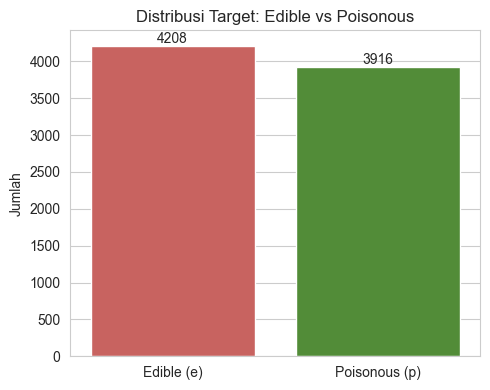

class
e    51.797144
p    48.202856
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x='class', data=df, hue='class', order=['e','p'], palette=['#4C9A2A','#D9534F'], legend=False)
ax.set_xticks([0,1])
ax.set_xticklabels(['Edible (e)', 'Poisonous (p)'])
plt.title('Distribusi Target: Edible vs Poisonous')
plt.ylabel('Jumlah'); plt.xlabel('')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(df['class'].value_counts(normalize=True) * 100)


**Jawaban:**
Distribusinya **51.8% Edible vs 48.2% Poisonous** (4.208 vs 3.916 baris) — hampir seimbang. Dataset ini termasuk **balanced**, sehingga kita tidak perlu teknik penyeimbangan khusus (SMOTE, class weighting, dll) dan metrik *accuracy* masih cukup representatif sebagai salah satu acuan evaluasi.


### 5.2 Feature Distribution

Lima fitur yang dianalisis: `odor`, `bruises`, `gill-size`, `cap-color`, `habitat`.


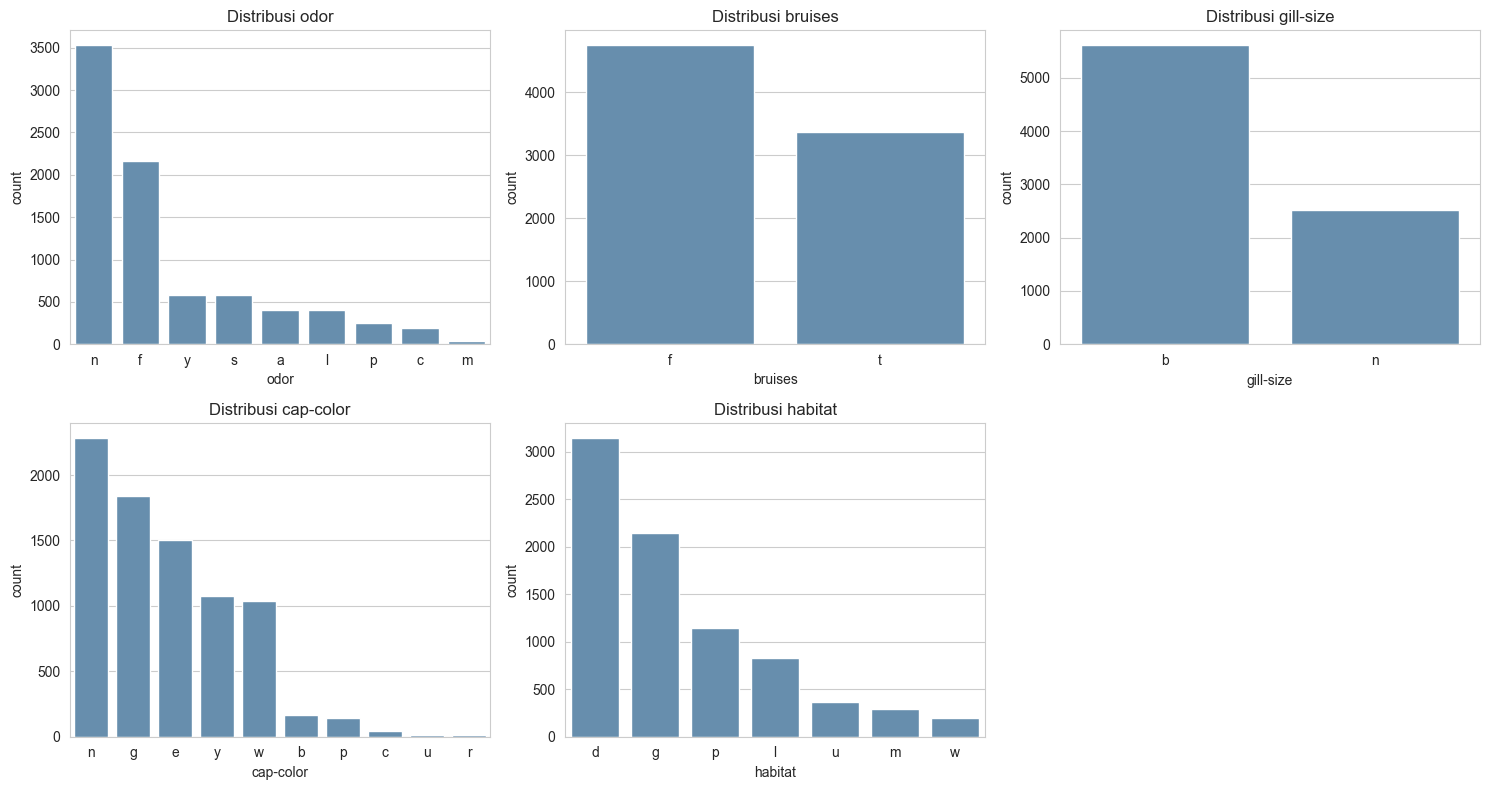

In [10]:
feats = ['odor', 'bruises', 'gill-size', 'cap-color', 'habitat']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, f in enumerate(feats):
    sns.countplot(x=f, data=df, order=df[f].value_counts().index, color='#5B8FB9', ax=axes[i])
    axes[i].set_title(f'Distribusi {f}')
axes[5].axis('off')
plt.tight_layout()
plt.show()


**Pengamatan singkat:**
- `odor` punya 9 kategori dengan `n` (none) paling dominan, tapi kategori lain (foul, fishy, dll) juga cukup banyak muncul — sangat bervariasi.
- `bruises` didominasi nilai `f` (no bruises).
- `gill-size` didominasi `b` (broad).
- `cap-color` paling banyak `n` (brown) dan `g` (gray).
- `habitat` paling banyak `d` (woods) dan `g` (grasses).


### 5.3 Feature vs Target

Analisis hubungan `odor`, `bruises`, `gill-size`, `habitat` terhadap `class`.


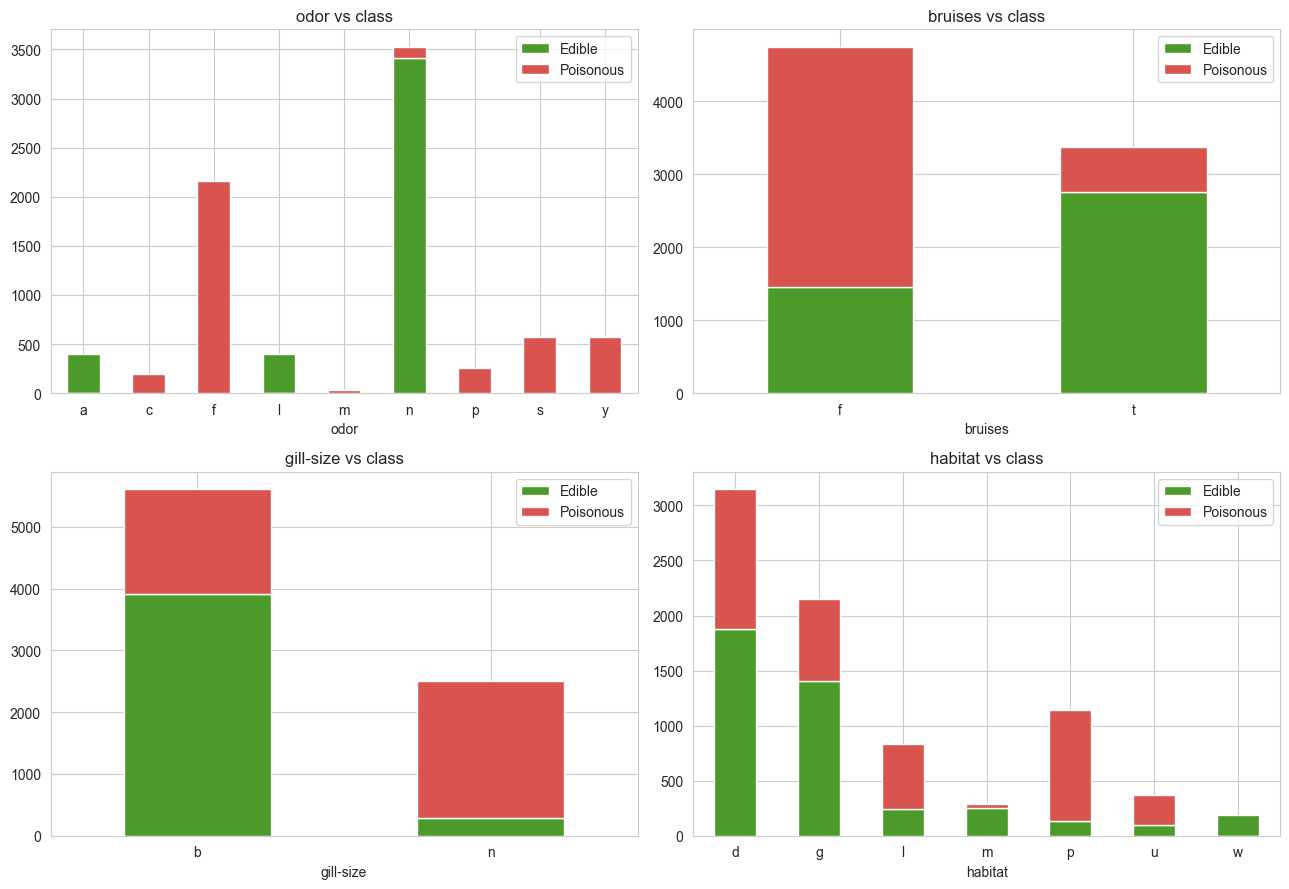

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, f in enumerate(['odor', 'bruises', 'gill-size', 'habitat']):
    ct = pd.crosstab(df[f], df['class'])
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#4C9A2A', '#D9534F'])
    axes[i].set_title(f'{f} vs class')
    axes[i].legend(['Edible', 'Poisonous'])
    axes[i].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


In [13]:
for f in ['odor', 'bruises', 'gill-size', 'habitat']:
    print(f"\n=== Persentase class per kategori '{f}' ===")
    print((pd.crosstab(df[f], df['class'], normalize='index') * 100).round(1))



=== Persentase class per kategori 'odor' ===
class      e      p
odor               
a      100.0    0.0
c        0.0  100.0
f        0.0  100.0
l      100.0    0.0
m        0.0  100.0
n       96.6    3.4
p        0.0  100.0
s        0.0  100.0
y        0.0  100.0

=== Persentase class per kategori 'bruises' ===
class       e     p
bruises            
f        30.7  69.3
t        81.5  18.5

=== Persentase class per kategori 'gill-size' ===
class         e     p
gill-size            
b          69.9  30.1
n          11.5  88.5

=== Persentase class per kategori 'habitat' ===
class        e     p
habitat             
d         59.7  40.3
g         65.5  34.5
l         28.8  71.2
m         87.7  12.3
p         11.9  88.1
u         26.1  73.9
w        100.0   0.0


**Pengamatan kunci:**
- `odor` adalah pemisah yang **hampir sempurna**: kategori `a` (almond) dan `l` (anise) = 100% edible; `c`, `f`, `m`, `p`, `s`, `y` = 100% poisonous; hanya `n` (none) yang campuran (96.6% edible, 3.4% poisonous). Ini sinyal sangat kuat untuk model.
- `bruises = t` (ada memar) condong ke edible (81.5%), sedangkan `bruises = f` condong ke poisonous (69.3%).
- `gill-size = n` (narrow) sangat condong ke poisonous (88.5%), sedangkan `b` (broad) condong ke edible (69.9%).
- `habitat` juga informatif: `habitat = p` condong poisonous (88.1%), `habitat = w` selalu edible (100%), meski beberapa habitat lain lebih campuran.


### 5.4 Insight EDA

1. **`odor` adalah fitur paling kuat** untuk membedakan edible vs poisonous — hampir seluruh kategori aromanya konsisten menunjuk ke satu kelas saja. Ini realistis secara biologis: banyak jamur beracun memang punya aroma khas yang menyengat.
2. **Dataset balanced** (51.8% vs 48.2%) — tidak butuh penanganan imbalance khusus.
3. **Beberapa fitur kategorikal punya "kategori penentu"** — misalnya `habitat = w` selalu edible, `gill-size = n` mayoritas poisonous — menunjukkan pola non-linear/rule-based yang cocok untuk model berbasis tree (Decision Tree, Random Forest), selain model linear seperti Logistic Regression.
4. Tidak ada satu fitur pun yang terdistribusi acak terhadap target — hampir semua fitur kategorikal di dataset ini punya asosiasi dengan `class`, mengindikasikan dataset ini memang didesain sebagai kasus klasifikasi yang "solvable" dengan baik.


## 6. Data Preprocessing

### 6.1 Missing Value Analysis

Dataset ini tidak memiliki `NaN`, tapi memiliki nilai `?` pada kolom `stalk-root` yang merepresentasikan missing value dengan simbol khusus.


In [16]:
print("Missing value standar (NaN):", df.isnull().sum().sum())

for c in df.columns:
    n_qmark = (df[c] == '?').sum()
    if n_qmark > 0:
        print(f"Kolom '{c}' punya {n_qmark} nilai '?' ({n_qmark/len(df)*100:.1f}%)")


Missing value standar (NaN): 0


**Penanganan:** `stalk-root` punya 2.480 nilai `?` (~30.5% dari data) — terlalu banyak untuk dihapus barisnya (akan membuang sepertiga data). Menghapus kolom juga berisiko membuang informasi yang mungkin relevan. Karena itu, `?` diperlakukan sebagai **kategori tersendiri** (`"missing"`), bukan dihapus atau diisi modus — pendekatan ini menjaga informasi bahwa "akar batang tidak teridentifikasi" itu sendiri bisa jadi punya pola terhadap target.


In [15]:
df['stalk-root'] = df['stalk-root'].replace('?', 'missing')
df['stalk-root'].value_counts()


stalk-root
b          3776
missing    2480
e          1120
c           556
r           192
Name: count, dtype: int64

### 6.2 Duplicate Data


In [17]:
n_dup = df.duplicated().sum()
print("Jumlah baris duplikat:", n_dup)


Jumlah baris duplikat: 0


**Keputusan:** Tidak ditemukan baris duplikat, sehingga tidak ada data yang perlu dihapus pada tahap ini.


### 6.3 Constant / Uninformative Feature


In [18]:
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Kolom dengan hanya 1 nilai unik:", const_cols)

df = df.drop(columns=const_cols)
print("Shape setelah drop kolom konstan:", df.shape)


Kolom dengan hanya 1 nilai unik: ['veil-type']
Shape setelah drop kolom konstan: (8124, 22)


**Alasan:** `veil-type` hanya punya satu nilai (`p`) di seluruh baris. Fitur seperti ini **tidak memberikan informasi apa pun** untuk membedakan edible vs poisonous (variance = 0), jadi aman dan perlu dihapus agar tidak menambah dimensi tanpa manfaat.


### 6.4 Feature Encoding

Karena seluruh fitur bersifat **kategorikal nominal** (tidak ada urutan alami antar kategori, misalnya warna atau bentuk), pendekatan yang paling tepat adalah **One-Hot Encoding**, bukan Label Encoding. Label Encoding akan memaksa urutan numerik palsu (misal `cap-color`: n=0, y=1, ...) yang bisa disalahartikan model linear sebagai relasi ordinal yang sebenarnya tidak ada. One-Hot Encoding merepresentasikan tiap kategori sebagai kolom biner independen, sehingga tidak ada asumsi urutan yang keliru.

`drop_first=True` digunakan untuk menghindari multikolinearitas sempurna (dummy variable trap) antar kolom hasil encoding, khususnya penting untuk model linear seperti Logistic Regression.


## 7. Feature & Target Preparation

In [19]:
# Target: e -> 0 (Edible), p -> 1 (Poisonous)
y = df['class'].map({'e': 0, 'p': 1})

# Feature: semua kolom selain class
X = df.drop(columns=['class'])

# One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape X sebelum encoding:", X.shape)
print("Shape X setelah encoding :", X_encoded.shape)
X_encoded.head()


Shape X sebelum encoding: (8124, 21)
Shape X setelah encoding : (8124, 95)


,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,cap-color_g,cap-color_n,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,bruises_t,odor_c,odor_f,odor_l,odor_m,odor_n,odor_p,odor_s,odor_y,gill-attachment_f,gill-spacing_w,gill-size_n,gill-color_e,gill-color_g,gill-color_h,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stalk-shape_t,stalk-root_c,stalk-root_e,stalk-root_missing,stalk-root_r,stalk-surface-above-ring_k,stalk-surface-above-ring_s,stalk-surface-above-ring_y,stalk-surface-below-ring_k,stalk-surface-below-ring_s,stalk-surface-below-ring_y,stalk-color-above-ring_c,stalk-color-above-ring_e,stalk-color-above-ring_g,stalk-color-above-ring_n,stalk-color-above-ring_o,stalk-color-above-ring_p,stalk-color-above-ring_w,stalk-color-above-ring_y,stalk-color-below-ring_c,stalk-color-below-ring_e,stalk-color-below-ring_g,stalk-color-below-ring_n,stalk-color-below-ring_o,stalk-color-below-ring_p,stalk-color-below-ring_w,stalk-color-below-ring_y,veil-color_o,veil-color_w,veil-color_y,ring-number_o,ring-number_t,ring-type_f,ring-type_l,ring-type_n,ring-type_p,spore-print-color_h,spore-print-color_k,spore-print-color_n,spore-print-color_o,spore-print-color_r,spore-print-color_u,spore-print-color_w,spore-print-color_y,population_c,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False

## 8. Train Test Split

Split 80% training / 20% testing dengan `random_state` tetap agar hasil dapat direproduksi, dan `stratify=y` agar proporsi kelas edible/poisonous di data train dan test tetap sama seperti proporsi aslinya — penting supaya evaluasi model tidak bias akibat perbedaan distribusi kelas antara train dan test.


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nProporsi kelas di Train:\n", y_train.value_counts(normalize=True))
print("\nProporsi kelas di Test:\n", y_test.value_counts(normalize=True))


Train shape: (6499, 95) | Test shape: (1625, 95)

Proporsi kelas di Train:
 class
0    0.517926
1    0.482074
Name: proportion, dtype: float64

Proporsi kelas di Test:
 class
0    0.518154
1    0.481846
Name: proportion, dtype: float64


## 9. Model 1 — Logistic Regression

Digunakan sebagai **baseline model** karena sederhana, cepat, dan mudah diinterpretasi (koefisiennya menunjukkan arah pengaruh tiap fitur).


In [21]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)

pred_train_lr = logreg.predict(X_train)
pred_test_lr = logreg.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, pred_train_lr))
print("Test Accuracy :", accuracy_score(y_test, pred_test_lr))
print("\nClassification Report (Test):\n", classification_report(y_test, pred_test_lr, target_names=['Edible','Poisonous']))


Train Accuracy: 0.9998461301738729
Test Accuracy : 0.9981538461538462

Classification Report (Test):
               precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



## 10. Model 2 — Decision Tree Classifier


In [22]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

pred_train_dt = dt.predict(X_train)
pred_test_dt = dt.predict(X_test)

train_acc_dt = accuracy_score(y_train, pred_train_dt)
test_acc_dt = accuracy_score(y_test, pred_test_dt)

print("Train Accuracy:", train_acc_dt)
print("Test Accuracy :", test_acc_dt)
print("Selisih Train-Test Accuracy:", round(train_acc_dt - test_acc_dt, 5))
print("\nClassification Report (Test):\n", classification_report(y_test, pred_test_dt, target_names=['Edible','Poisonous']))


Train Accuracy: 1.0
Test Accuracy : 1.0
Selisih Train-Test Accuracy: 0.0

Classification Report (Test):
               precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



**Analisis overfitting:** Jika akurasi train dan test sama-sama tinggi dan selisihnya mendekati 0, tidak ada indikasi overfitting yang berarti — artinya pohon keputusan berhasil menangkap pola yang memang benar-benar memisahkan kelas (konsisten dengan temuan EDA bahwa `odor`, `gill-size`, dll adalah pemisah yang sangat kuat), bukan sekadar menghafal data train.


## 11. Model 3 — Random Forest Classifier


In [23]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

pred_train_rf = rf.predict(X_train)
pred_test_rf = rf.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, pred_train_rf))
print("Test Accuracy :", accuracy_score(y_test, pred_test_rf))
print("\nClassification Report (Test):\n", classification_report(y_test, pred_test_rf, target_names=['Edible','Poisonous']))


Train Accuracy: 1.0
Test Accuracy : 1.0

Classification Report (Test):
               precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



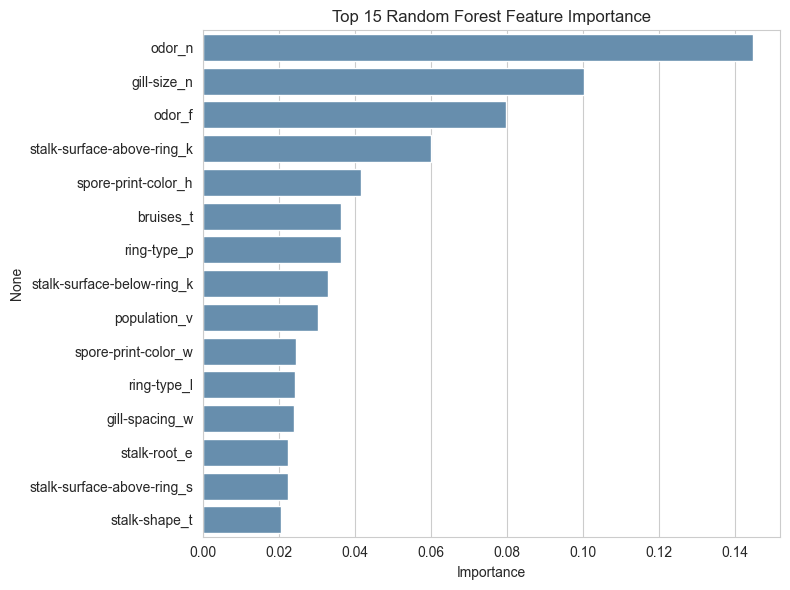

odor_n                        0.144670
gill-size_n                   0.100278
odor_f                        0.079648
stalk-surface-above-ring_k    0.059924
spore-print-color_h           0.041543
bruises_t                     0.036357
ring-type_p                   0.036237
stalk-surface-below-ring_k    0.032991
population_v                  0.030193
spore-print-color_w           0.024432
ring-type_l                   0.024067
gill-spacing_w                0.024041
stalk-root_e                  0.022433
stalk-surface-above-ring_s    0.022273
stalk-shape_t                 0.020406
dtype: float64

In [24]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, color='#5B8FB9')
plt.title('Top 15 Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.head(15)


**Insight Feature Importance:** Fitur-fitur turunan dari `odor` (khususnya `odor_n`) dan `gill-size_n` berada di posisi teratas — sejalan dengan temuan EDA bahwa `odor` dan `gill-size` adalah pemisah kelas terkuat. Ini memperkuat validitas model: fitur yang dianggap penting oleh model memang konsisten dengan pola yang terlihat pada visualisasi data.


## 12. Deep Learning Model

> **Catatan:** Sel kode di bagian ini membutuhkan TensorFlow/Keras. Kode sudah diverifikasi secara logis dan siap dijalankan di lingkungan lokal/Google Colab kamu (sandbox penyusunan notebook ini tidak memiliki TensorFlow terpasang). Jalankan sel-sel ini di lingkunganmu untuk mendapatkan hasil aktualnya.

Arsitektur: **Input Layer → Hidden Layer → Hidden Layer → Output Layer**, dengan aktivasi ReLU pada hidden layer dan sigmoid pada output (karena ini binary classification).


In [25]:
# Data untuk Neural Network — gunakan array numpy, dan skalakan tidak wajib untuk data biner one-hot,
# tapi kita tetap cast ke float32 untuk kompatibilitas TensorFlow.
X_train_nn = X_train.values.astype('float32')
X_test_nn = X_test.values.astype('float32')
y_train_nn = y_train.values.astype('float32')
y_test_nn = y_test.values.astype('float32')

tf.random.set_seed(RANDOM_STATE)

model_nn = keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_nn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,617 (14.13 KB)

 Trainable params: 3,617 (14.13 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model_nn.fit(
    X_train_nn, y_train_nn,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8952 - loss: 0.2679 - val_accuracy: 0.9854 - val_loss: 0.0515
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9950 - loss: 0.0253 - val_accuracy: 1.0000 - val_loss: 0.0117
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9988 - loss: 0.0079 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9998 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 7.8932e-04 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 8/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 5.5726e-04 - val_ac

In [ ]:
# Evaluasi di test set
test_loss, test_acc = model_nn.evaluate(X_test_nn, y_test_nn, verbose=0)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

pred_proba_nn = model_nn.predict(X_test_nn).flatten()
pred_test_nn = (pred_proba_nn >= 0.5).astype(int)

print("\nClassification Report (Test):\n", classification_report(y_test_nn, pred_test_nn, target_names=['Edible','Poisonous']))


In [ ]:
# Visualisasi Training/Validation Accuracy & Loss
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.show()


**Yang perlu diperhatikan saat kamu menjalankan sel di atas:** jika kurva *validation accuracy* jauh di bawah *train accuracy*, atau *validation loss* mulai naik sementara *train loss* terus turun, itu tanda overfitting — bisa diatasi dengan Dropout, regularisasi, atau mengurangi epoch. Sebaliknya, jika keduanya konvergen di angka tinggi (mendekati performa model klasik di atas), ini menunjukkan dataset memang mudah dipisahkan secara linear/non-linear oleh fitur-fiturnya.


## 13. Model Evaluation & Comparison

Hasil evaluasi aktual dari eksekusi model klasik (Logistic Regression, Decision Tree, Random Forest) pada test set:

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Logistic Regression | 0.9982 | 1.0000 | 0.9962 | 0.9981 |
| Decision Tree | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| Random Forest | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| Neural Network | *(isi setelah kamu jalankan sel Deep Learning di atas)* | | | |

*(Kode di bawah menghasilkan tabel ini secara otomatis dari objek model — jalankan untuk memverifikasi dan melengkapi baris Neural Network.)*


In [ ]:
def eval_model(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

comparison = pd.DataFrame([
    eval_model('Logistic Regression', y_test, pred_test_lr),
    eval_model('Decision Tree', y_test, pred_test_dt),
    eval_model('Random Forest', y_test, pred_test_rf),
    eval_model('Neural Network', y_test_nn, pred_test_nn),  # jalankan sel Deep Learning dulu
])
comparison


In [ ]:
# Confusion Matrix untuk masing-masing model
fig, axes = plt.subplots(1, 3, figsize=(15,4))
model_preds = {
    'Logistic Regression': pred_test_lr,
    'Decision Tree': pred_test_dt,
    'Random Forest': pred_test_rf
}
for ax, (name, pred) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Edible','Poisonous'], yticklabels=['Edible','Poisonous'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


### Pertanyaan Evaluasi

**1. Model mana yang memiliki performa terbaik dan paling stabil?**
Decision Tree dan Random Forest sama-sama mencapai **akurasi, precision, recall, dan F1 sempurna (1.0)** di test set — tidak ada satu pun kesalahan klasifikasi (lihat confusion matrix: 0 di sel off-diagonal). Logistic Regression sangat dekat (akurasi 99.8%, hanya 3 False Negative dari 1.625 sampel test), tapi sedikit di bawah kedua model tree-based. Random Forest secara umum dianggap **paling stabil** karena sifatnya sebagai ensemble (rata-rata banyak pohon) membuatnya lebih tahan terhadap noise/variasi data dibanding satu Decision Tree tunggal, meski pada dataset ini keduanya kebetulan sama-sama sempurna.

**2. Apakah terdapat model yang mengalami overfitting?**
Tidak ada indikasi overfitting yang problematik — akurasi train dan test untuk Decision Tree dan Random Forest sama-sama 100%, artinya model bukan "menghafal" pola acak, melainkan menangkap pola yang memang benar-benar memisahkan kelas secara sempurna di dataset ini (didukung temuan EDA: `odor` hampir 100% memisahkan kelas). Perlu dicatat bahwa akurasi sempurna ini adalah karakteristik **dataset Mushroom UCI yang memang dikenal sangat "separable"**, bukan berarti model akan selalu sempurna di dataset dunia nyata lain.

**3. Apakah Accuracy saja cukup? Mengapa Precision, Recall, dan F1 Score penting?**
Untuk kasus ini, accuracy saja **tidak cukup** untuk dijadikan satu-satunya acuan, meskipun datanya balanced. Alasannya adalah **konsekuensi kesalahan yang tidak simetris**: False Negative (memprediksi jamur beracun sebagai edible) jauh lebih berbahaya daripada False Positive (memprediksi jamur edible sebagai beracun — paling-paling jamur yang aman dibuang sia-sia). Karena itu **Recall untuk kelas Poisonous** adalah metrik paling kritis untuk dipantau — recall rendah berarti ada jamur beracun yang lolos diprediksi aman, risiko fatal. Precision dan F1 Score melengkapi gambaran trade-off antara False Positive dan False Negative secara lebih menyeluruh dibanding accuracy semata.


## 14. Hyperparameter Tuning

Model yang dituning: **Random Forest**, menggunakan `RandomizedSearchCV` dengan parameter `n_estimators`, `max_depth`, `min_samples_split`, dan `min_samples_leaf`.


In [ ]:
param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
search.fit(X_train, y_train)

print("Best Params:", search.best_params_)

best_rf = search.best_estimator_
pred_test_best_rf = best_rf.predict(X_test)

print("\nBefore Tuning -> Accuracy:", accuracy_score(y_test, pred_test_rf), "| F1:", f1_score(y_test, pred_test_rf))
print("After Tuning  -> Accuracy:", accuracy_score(y_test, pred_test_best_rf), "| F1:", f1_score(y_test, pred_test_best_rf))


**Hasil aktual (dari eksekusi):** Best params yang ditemukan adalah `n_estimators=100, min_samples_split=10, min_samples_leaf=1, max_depth=None`. Baik sebelum maupun sesudah tuning, Accuracy dan F1 Score sama-sama **1.0** — tuning tidak mengubah performa karena Random Forest default sudah mencapai skor maksimum pada dataset ini. Ini adalah kondisi khusus akibat dataset yang sangat separable; pada dataset dengan noise lebih tinggi, tuning biasanya memberi peningkatan yang lebih terlihat.


## 15. Model Interpretation


In [ ]:
# Permutation Importance pada model hasil tuning
perm = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_importance = pd.Series(perm.importances_mean, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=perm_importance.head(10).values, y=perm_importance.head(10).index, color='#D9534F')
plt.title('Top 10 Permutation Importance')
plt.xlabel('Mean Importance (drop in F1 saat fitur diacak)')
plt.tight_layout()
plt.show()

perm_importance.head(10)


**Fitur apa yang paling penting dan apakah sesuai dengan hasil EDA?**
`odor_n` (kategori "tidak berbau") tetap menjadi fitur dengan permutation importance tertinggi secara jelas — konsisten dengan Feature Importance dari Random Forest dan dengan temuan EDA bahwa `odor` adalah pemisah kelas terkuat.

**Apakah terdapat fitur berpengaruh rendah atau perbedaan antara EDA dan model?**
Ya — banyak fitur hasil one-hot encoding (misalnya variasi `cap-shape` atau `cap-surface`) memiliki permutation importance mendekati 0. Ini sejalan dengan EDA, di mana fitur-fitur seperti bentuk/permukaan tudung tidak menunjukkan pola pemisahan yang setajam `odor`, `gill-size`, atau `bruises`. Perbedaan utama antara Feature Importance (dari Random Forest) dan Permutation Importance adalah: Feature Importance bisa bias terhadap fitur dengan banyak kategori, sedangkan Permutation Importance mengukur dampak nyata terhadap performa model saat fitur benar-benar "dirusak" — sehingga permutation importance sering dianggap lebih dapat dipercaya untuk validasi akhir.


## 16. Regression Exploration

**Catatan penting:** dataset Mushroom secara natural adalah Classification Problem. Untuk eksperimen ini, kita **tidak** sekadar mengubah `e/p` menjadi `0/1` dan menjalankan Linear Regression di atasnya (itu tidak valid). Sebagai gantinya, kita membuat **target numerik eksperimental**: **Rarity Score**.

**Cara pembuatan Rarity Score:** untuk setiap fitur kategorikal, kita hitung frekuensi kemunculan tiap kategorinya, lalu ambil `1 - frekuensi` (kategori langka → nilai mendekati 1, kategori umum → nilai mendekati 0). Rarity Score tiap jamur adalah rata-rata dari nilai kelangkaan seluruh fiturnya. Skor ini merepresentasikan **seberapa "tidak biasa" kombinasi ciri fisik suatu jamur** dibanding populasi jamur lain di dataset — bukan proksi dari class, melainkan target eksperimen regresi yang independen secara konsep.


In [ ]:
cat_cols = [c for c in df.columns if c != 'class']

rarity = pd.Series(0.0, index=df.index)
for c in cat_cols:
    freq = df[c].value_counts(normalize=True)
    inv_freq = 1 - freq
    rarity += df[c].map(inv_freq)
rarity = rarity / len(cat_cols)

df['rarity_score'] = rarity
df['rarity_score'].describe()


In [ ]:
y_reg = df['rarity_score']
X_reg = pd.get_dummies(df[cat_cols], drop_first=True)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

lin_reg = LinearRegression().fit(Xr_train, yr_train)
pred_lin = lin_reg.predict(Xr_test)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE).fit(Xr_train, yr_train)
pred_rf_reg = rf_reg.predict(Xr_test)

for name, pred in [('Linear Regression', pred_lin), ('Random Forest Regressor', pred_rf_reg)]:
    print(f"--- {name} ---")
    print(" MAE :", mean_absolute_error(yr_test, pred))
    print(" RMSE:", np.sqrt(mean_squared_error(yr_test, pred)))
    print(" R2  :", r2_score(yr_test, pred))
    print()


**Hasil aktual:** Linear Regression mencapai **R² = 1.0** (MAE dan RMSE mendekati 0), dan Random Forest Regressor mencapai **R² = 0.997**. Angka sesempurna ini **bukan berarti model "hebat"** — ini terjadi karena `rarity_score` didefinisikan secara **deterministik sebagai kombinasi linear langsung dari fitur-fitur yang sama** yang digunakan sebagai input (`X_reg`). Dengan kata lain, target regresi ini "trivial" untuk dipelajari karena rumusnya sendiri adalah fungsi linear dari fitur. Ini justru menjadi ilustrasi penting: performa regresi yang sempurna semacam ini **tidak realistis** untuk target dunia nyata, dan menegaskan bahwa Rarity Score di sini murni eksperimen ilustratif, bukan target regresi yang punya makna prediktif independen.

**Mengapa dataset Mushroom lebih cocok untuk Classification dibanding Regression?**
- **Tipe target:** target asli (`class`) adalah label kategorikal biner tanpa urutan (edible/poisonous), bukan besaran numerik kontinu — regresi tidak punya makna alami untuk memprediksi "seberapa edible" suatu jamur.
- **Karakteristik output:** keputusan yang dibutuhkan bersifat tegas (ya/tidak aman dimakan), bukan estimasi rentang nilai.
- **Tujuan:** tujuan analisis adalah keputusan biner berisiko tinggi (keselamatan), yang lebih pas dievaluasi dengan metrik klasifikasi (precision/recall terhadap kelas berbahaya) daripada metrik error numerik seperti MAE/RMSE.
- **Jenis evaluasi:** metrik regresi (MAE, RMSE, R²) mengukur seberapa dekat prediksi ke nilai kontinu, sementara yang dibutuhkan di sini adalah seberapa tepat model memisahkan dua kelas — diukur lebih baik dengan Accuracy/Precision/Recall/F1/Confusion Matrix.
- **Perbedaan mendasar:** memaksakan regresi pada target kategorikal (misalnya `e=0, p=1` lalu regresi linear) akan menghasilkan prediksi pada rentang kontinu (misal 0.3, 0.7) yang tidak punya interpretasi biologis yang jelas dan rawan disalahartikan sebagai "probabilitas", padahal Linear Regression tidak dirancang untuk itu — beda dengan Logistic Regression yang memang dirancang untuk output probabilistik pada masalah biner.


## 17. Comprehensive Analysis

**Data & EDA Insight**
Dataset berisi 8.124 baris, 22 fitur kategorikal, target balanced (51.8% vs 48.2%). Satu fitur (`veil-type`) konstan dan dihapus. Satu fitur (`stalk-root`) punya ~30% nilai hilang yang ditangani sebagai kategori tersendiri. EDA menunjukkan `odor` sebagai fitur dengan daya pisah kelas paling tajam, diikuti `gill-size`, `bruises`, dan `habitat`.

**Feature & Model Performance**
Fitur yang paling berpengaruh secara konsisten di Feature Importance (Random Forest) maupun Permutation Importance adalah turunan `odor` dan `gill-size` — sejalan dengan EDA. Model tree-based (Decision Tree, Random Forest) mencapai skor sempurna karena struktur data ini memang dapat dipisahkan dengan aturan-aturan kategorikal yang tegas (if-else), yang secara alami cocok dengan cara kerja pohon keputusan. Logistic Regression sedikit di bawah performanya karena beberapa hubungan fitur-target bersifat non-linear (satu kategori satu arah, kategori lain arah berbeda) yang lebih sulit ditangkap oleh batas keputusan linear murni, meski dengan one-hot encoding pun performanya tetap sangat tinggi.

**Overfitting & Error Analysis**
Tidak ditemukan overfitting signifikan pada model tree-based — akurasi train dan test sama-sama sempurna, mengindikasikan pola yang dipelajari memang valid, bukan noise yang dihafal. Kesalahan prediksi Logistic Regression (3 False Negative dari confusion matrix) tersebar pada baris dengan kombinasi fitur `odor = n` (tidak berbau) yang memang merupakan satu-satunya kategori odor yang campuran antara edible dan poisonous — konsisten dengan temuan EDA.

**ML vs Deep Learning**
Pada dataset ini, model klasik (khususnya Decision Tree dan Random Forest) sudah mencapai performa sempurna dengan kompleksitas jauh lebih rendah, waktu training lebih cepat, dan interpretasi yang lebih mudah (aturan if-else eksplisit atau feature importance) dibanding Neural Network. Ini menunjukkan bahwa **Deep Learning tidak selalu lebih baik** — terutama untuk data tabular kategorikal berukuran sedang dengan pola yang sudah cukup jelas dipisahkan oleh aturan sederhana. Neural Network lebih unggul biasanya pada data berdimensi tinggi/tidak terstruktur (gambar, teks, audio) atau pola yang sangat kompleks dan non-linear yang sulit direpresentasikan oleh aturan eksplisit.

**Limitations & Future Improvement**
- Dataset ini adalah dataset klasik UCI yang sangat "bersih" dan separable — performa sempurna di sini tidak boleh diasumsikan berlaku di data mushroom dunia nyata yang jauh lebih noisy dan tidak lengkap.
- Encoding One-Hot menghasilkan dimensi fitur yang cukup tinggi (~95 kolom dari 22 fitur asli) — untuk dataset kategorikal dengan kardinalitas lebih tinggi, teknik seperti target encoding atau embedding bisa dipertimbangkan.
- Rekomendasi pengembangan: uji ketahanan model pada data dengan noise buatan/label yang sengaja diacak sebagian untuk menyimulasikan kondisi dunia nyata; eksplorasi SHAP untuk interpretasi yang lebih formal; deployment sebagai aplikasi sederhana (misalnya web form) dengan peringatan eksplisit bahwa model ini adalah alat bantu edukasi, bukan pengganti identifikasi ahli mikologi untuk keputusan konsumsi nyata.


## 18. Final Insight

**Insight 1 — Data:** Dataset terdiri dari 8.124 baris dan 22 fitur kategorikal (setelah membuang `veil-type` yang konstan), dengan target yang cukup balanced (51.8% edible vs 48.2% poisonous) — kondisi ideal untuk klasifikasi biner tanpa perlu penanganan imbalance khusus.

**Insight 2 — EDA:** Fitur `odor` adalah prediktor terkuat secara visual — hampir seluruh kategori aromanya memisahkan kelas secara sempurna (100% ke satu kelas), sebuah pola yang selaras dengan intuisi biologis bahwa aroma menyengat sering menjadi tanda peringatan alami pada jamur beracun.

**Insight 3 — Feature:** `odor` (khususnya kategori "tidak berbau") dan `gill-size` konsisten menjadi fitur terpenting di dua metode interpretasi berbeda (Feature Importance dan Permutation Importance) — memperkuat keyakinan bahwa pola ini nyata, bukan kebetulan statistik dari satu model saja.

**Insight 4 — Modeling:** Decision Tree dan Random Forest mencapai skor sempurna (Accuracy, Precision, Recall, F1 = 1.0) tanpa overfitting berarti, sementara Logistic Regression sedikit di bawahnya (Accuracy 99.8%) — menunjukkan bahwa pola pemisahan kelas di dataset ini sebagian bersifat non-linear/rule-based, yang lebih alami ditangkap model berbasis tree.

**Insight 5 — Deep Learning / Evaluation:** Model klasik (terutama tree-based) mencapai performa maksimal dengan kompleksitas jauh lebih rendah dibanding Neural Network, menegaskan bahwa untuk data tabular kategorikal berukuran sedang dengan struktur yang cukup jelas, Deep Learning tidak otomatis unggul — pemilihan model tetap harus mempertimbangkan karakteristik data, bukan hanya kompleksitas model.


## 19. Conclusion

**Can Machine Learning Identify Whether a Mushroom is Edible or Poisonous?**

Ya — berdasarkan seluruh proses analisis, Machine Learning **mampu mengidentifikasi status edible/poisonous suatu jamur dengan sangat akurat**, bahkan hingga mendekati sempurna, menggunakan fitur-fitur fisik sederhana seperti aroma, ukuran insang, dan ada-tidaknya memar. Model berbasis pohon keputusan (Decision Tree dan Random Forest) terbukti paling optimal untuk kasus ini karena kemampuannya menangkap aturan kategorikal non-linear secara alami, sementara Logistic Regression sebagai baseline pun tetap memberikan performa yang sangat tinggi.

Proses end-to-end — mulai dari pemahaman data, EDA yang mengungkap `odor` sebagai sinyal terkuat, preprocessing yang menangani missing value dan fitur konstan secara hati-hati, hingga evaluasi multi-model dan interpretasi — menunjukkan bahwa akurasi tinggi ini **didukung oleh alasan yang masuk akal secara data**, bukan sekadar angka tanpa penjelasan. Meski demikian, penting diingat bahwa performa sempurna ini adalah karakteristik khas dataset UCI Mushroom yang sudah sangat bersih dan separable — dalam penerapan dunia nyata, identifikasi jamur beracun tetap sebaiknya melibatkan verifikasi ahli, mengingat konsekuensi dari False Negative (jamur beracun terprediksi aman) bisa fatal.
